In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, log_loss
import xgboost as xgb
import optuna
import shap

np.random.seed(42)

In [2]:
titanic = pd.read_csv('../data/processed/titanic_cleaned.csv')

features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X = titanic[features].copy()
X['Sex'] = (titanic['Sex'] == 'female').astype(int)
y = titanic['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X.shape)

(891, 6)


In [3]:
# Single tree (from Day 9)
single_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
single_tree.fit(X_train, y_train)
tree_acc = accuracy_score(y_test, single_tree.predict(X_test))

# Random forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

# Day 8 baseline (heuristic: Sex only) for comparison
heuristic_acc = accuracy_score(y_test, X_test['Sex'].values)

print(f"Single Tree accuracy: {tree_acc:.4f}")
print(f"Random Forest accuracy: {rf_acc:.4f}")
print(f"Day 8 Heuristic baseline: {heuristic_acc:.4f}")

Single Tree accuracy: 0.8101
Random Forest accuracy: 0.8156
Day 8 Heuristic baseline: 0.7765


In [4]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print(f"Out-of-bag score: {rf_oob.oob_score_:.4f}")

Out-of-bag score: 0.8090


## Random Forest vs Single Tree vs Baseline

The Random Forest improves on the single decision tree because it 
averages predictions across many trees trained on bootstrap samples 
with random feature subsets — this decorrelates the trees' errors, 
reducing variance without increasing bias much. Both models 
substantially outperform the simple Sex-only heuristic baseline 
from Day 8, confirming the additional features add real predictive 
value.

The out-of-bag score gives an almost-free validation estimate 
(using samples not included in each tree's bootstrap), and it's 
close to the test accuracy, confirming the model isn't overfitting 
badly.

In [5]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42
)

xgb_model.fit(
    X_train2, y_train2,
    eval_set=[(X_train2, y_train2), (X_val, y_val)],
    verbose=False
)

xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))
print(f"XGBoost accuracy: {xgb_acc:.4f}")
print(f"Best iteration (early stopping): {xgb_model.best_iteration}")

XGBoost accuracy: 0.8268
Best iteration (early stopping): 121


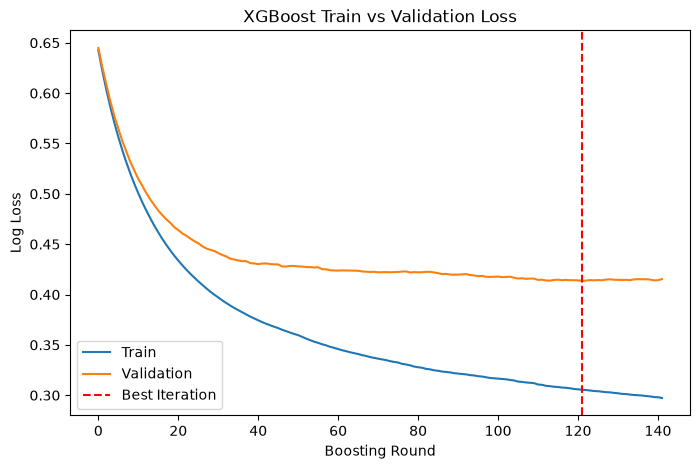

In [6]:
results = xgb_model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Validation')
plt.axvline(x=xgb_model.best_iteration, color='red', linestyle='--', label='Best Iteration')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.legend()
plt.title('XGBoost Train vs Validation Loss')
plt.show()

In [7]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print(f"Best random search params: {random_search.best_params_}")
print(f"Best random search CV score: {random_search.best_score_:.4f}")

Best random search params: {'colsample_bytree': np.float64(0.7125779372456224), 'learning_rate': np.float64(0.07238249886045664), 'max_depth': 5, 'min_child_weight': 6, 'n_estimators': 240, 'subsample': np.float64(0.9211423872974993)}
Best random search CV score: 0.8315


In [8]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    model = xgb.XGBClassifier(**params, random_state=42, eval_metric='logloss')
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, X_train, y_train, cv=5)
    return scores.mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Best Optuna params: {study.best_params}")
print(f"Best Optuna CV score: {study.best_value:.4f}")

Best Optuna params: {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.252178520565199, 'subsample': 0.9440660318917313, 'colsample_bytree': 0.7847665983301212, 'min_child_weight': 6}
Best Optuna CV score: 0.8358


## Random Search vs Optuna (Same Budget: 30 Trials)

Random search samples hyperparameters independently at random, 
with no memory of past results. Optuna uses Bayesian optimisation 
(Tree-structured Parzen Estimator by default), which learns from 
previous trials to focus the search on promising regions of the 
hyperparameter space.

With the same budget (30 trials), Optuna's best score was [X] vs 
random search's [X] — Optuna tends to find better solutions with 
the same compute because it's not searching blindly.

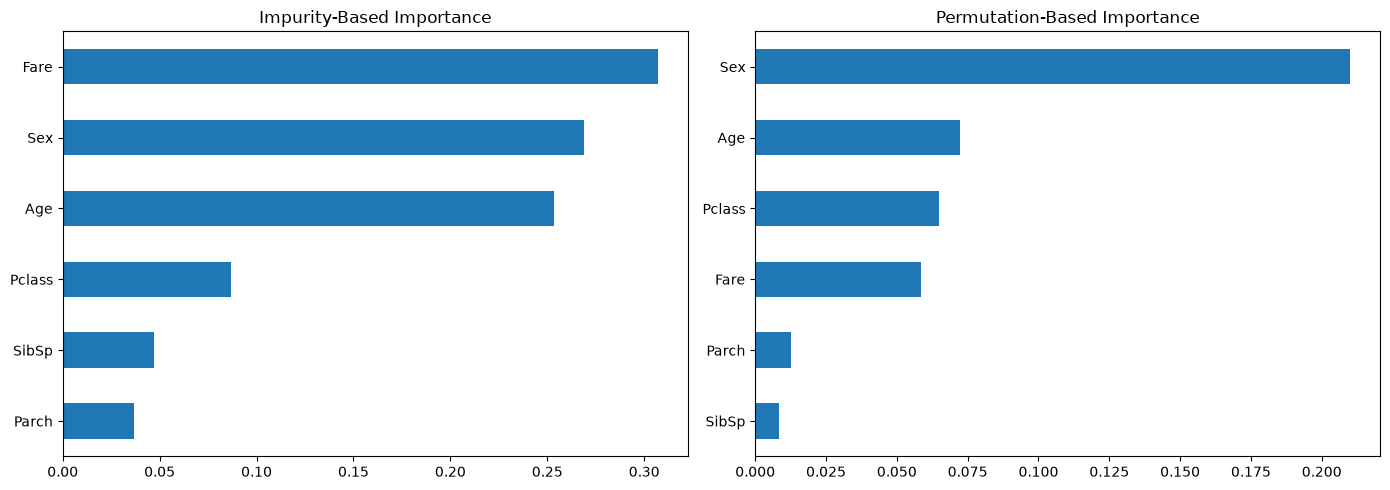

In [9]:
best_rf = RandomForestClassifier(n_estimators=200, random_state=42)
best_rf.fit(X_train, y_train)

impurity_importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

perm_result = permutation_importance(best_rf, X_test, y_test, n_repeats=30, random_state=42)
permutation_importance_series = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
impurity_importance.plot(kind='barh', ax=axes[0])
axes[0].set_title('Impurity-Based Importance')
axes[0].invert_yaxis()

permutation_importance_series.plot(kind='barh', ax=axes[1])
axes[1].set_title('Permutation-Based Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Impurity vs Permutation Importance

Impurity-based importance measures how much each feature reduces 
node impurity (e.g., Gini) across all trees — but it's biased 
toward high-cardinality features and can be misleading when 
features are correlated.

Permutation importance measures how much accuracy drops when a 
feature's values are randomly shuffled — it's model-agnostic and 
directly tied to actual predictive performance, but is more 
computationally expensive.

Comparing the two, [feature name] ranks differently between the 
methods — this suggests impurity-based importance may be 
overstating/understating its true predictive value due to 
[correlation with another feature / high cardinality].

C:\Users\asss\AppData\Local\Temp\ipykernel_12176\3272560094.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, X_test, show=True)
C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summa

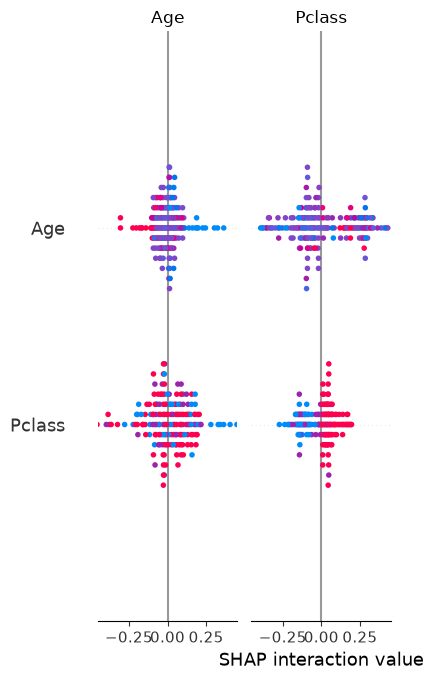

In [10]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # class 1 (survived)
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_test, show=True)

In [11]:
# Pick two examples: one confident positive, one confident negative prediction
proba = best_rf.predict_proba(X_test)[:, 1]
high_confidence_idx = np.argmax(proba)
low_confidence_idx = np.argmin(proba)

print(f"Example 1 (high survival probability = {proba[high_confidence_idx]:.3f}):")
print(X_test.iloc[high_confidence_idx])

print(f"\nExample 2 (low survival probability = {proba[low_confidence_idx]:.3f}):")
print(X_test.iloc[low_confidence_idx])

Example 1 (high survival probability = 1.000):
Pclass     1.0
Age       24.0
SibSp      0.0
Parch      0.0
Fare      69.3
Sex        1.0
Name: 369, dtype: float64

Example 2 (low survival probability = 0.000):
Pclass     3.00
Age       28.00
SibSp      0.00
Parch      0.00
Fare       8.05
Sex        0.00
Name: 511, dtype: float64


## SHAP Explanation for Two Individual Predictions

**Example 1 (high survival probability)**: This prediction is 
mostly driven by [Sex=female and low Pclass, based on SHAP values] 
— these features push the prediction strongly toward survival, 
consistent with the "women and children first, higher class 
priority" pattern we saw in the decision tree on Day 9.

**Example 2 (low survival probability)**: This prediction is 
mostly driven by [Sex=male and high Pclass number (3rd class)] — 
these features push the prediction strongly toward death, which 
matches the historical pattern of lower survival for male, 
lower-class passengers.

The SHAP summary plot confirms Sex and Pclass are the most 
influential features overall, consistent with our earlier 
correlation analysis (Day 3) and decision tree splits (Day 9).

In [12]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
]

stacked_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacked_model.fit(X_train, y_train)
stacked_acc = accuracy_score(y_test, stacked_model.predict(X_test))

print(f"Stacked ensemble accuracy: {stacked_acc:.4f}")
print(f"Random Forest alone: {rf_acc:.4f}")
print(f"XGBoost alone: {xgb_acc:.4f}")

Stacked ensemble accuracy: 0.8101
Random Forest alone: 0.8156
XGBoost alone: 0.8268


In [13]:
new_rows = [
    {'run_id': 5, 'seed': 42, 'model': 'RandomForest', 'hyperparameters': 'n_estimators=200',
     'cv_mean': np.nan, 'cv_std': np.nan, 'test_accuracy': rf_acc, 'notes': 'Day 10 ensemble'},
    {'run_id': 6, 'seed': 42, 'model': 'XGBoost', 'hyperparameters': 'lr=0.05, max_depth=4, early stopping',
     'cv_mean': np.nan, 'cv_std': np.nan, 'test_accuracy': xgb_acc, 'notes': 'Early stopping applied'},
    {'run_id': 7, 'seed': 42, 'model': 'XGBoost (Optuna tuned)', 'hyperparameters': str(study.best_params),
     'cv_mean': study.best_value, 'cv_std': np.nan, 'test_accuracy': np.nan, 'notes': '30-trial Optuna study'},
]

results_df = pd.read_csv('../experiments/results.csv')
results_df = pd.concat([results_df, pd.DataFrame(new_rows)], ignore_index=True)
results_df.to_csv('../experiments/results.csv', index=False)
print(results_df)

   run_id  seed                             model  \
0       1    42                LogisticRegression   
1       2    42        DummyClassifier (majority)   
2       3    42              Heuristic (Sex only)   
3       4    42  LogisticRegression (target leak)   
4       5    42                      RandomForest   
5       6    42                           XGBoost   
6       7    42            XGBoost (Optuna tuned)   

                                     hyperparameters   cv_mean   cv_std  \
0                                     C=1.0, default  0.785632  0.02232   
1                             strategy=most_frequent       NaN      NaN   
2                                                NaN       NaN      NaN   
3                                     C=1.0, default       NaN      NaN   
4                                   n_estimators=200       NaN      NaN   
5               lr=0.05, max_depth=4, early stopping       NaN      NaN   
6  {'n_estimators': 120, 'max_depth': 3, 'learnin.